INTRODUCTION:

This assignment explores outdoor wireless signal behavior and its application in location estimation using Python. The objective is to simulate Reference Signal Received Power (RSRP) across a set of receivers and analyze how well signal-based similarity corresponds to actual geographic proximity in an urban environment.

The simulation uses the Free-Space Path Loss (FSPL) model to compute received signal strength between transmitters and receivers. Distances between locations are calculated using the Haversine formula, providing accurate real-world separation based on GPS coordinates. RSRP values are then normalized to ensure fair comparisons between receivers, enabling the use of Euclidean distance in the signal feature space.

By comparing test receivers to a training dataset using signal profiles, the assignment applies a nearest-neighbor matching strategy to predict locations. These predictions are validated by comparing them to the physically closest training receivers. A variety of plots are generated, including geospatial layouts over Manhattan and distance profile comparisons, to visualize and interpret the results.

This project highlights the relationship between signal strength patterns and physical positioning in outdoor settings, offering valuable insights into the challenges and potential of signal-based localization techniques in urban wireless networks.

Using OSMnx, the code downloads polygon footprints of buildings in Manhattan.

These polygons will later help visualize the environment where transmitters and receivers are placed.

In [ ]:
# ---- Step 1: Download Manhattan buildings footprint
place = "Manhattan, New York, USA"
print("Downloading building footprints for Manhattan...")
buildings = ox.geometries_from_place(place, tags={"building": True})
print(f"Downloaded {len(buildings)} buildings.")

Three transmitters (Tx) are placed at specified latitudes and longitudes.

Antenna height is set but not directly used in the current simulation.

In [ ]:
# ---- Step 2: Transmitter positions (lat/lon)
tx_lats = np.array([40.7792, 40.7736, 40.7835])
tx_lons = np.array([-73.9693, -73.9659, -73.9630])
tx_antenna_height = 78


Creates a grid of receiver (Rx) positions covering the target area.

Grid size: 8 rows × 2 columns.

Receiver altitude (rx_z_train) is fixed at 100m.

In [ ]:
# ---- Step 3: Training receiver grid (8 rows x 2 cols)
num_rows_train = 8
num_cols_train = 2

lat_min = 40.7736
lat_max = 40.7840
lon_min = -73.9740
lon_max = -73.9600

rx_lats_train = np.linspace(lat_min, lat_max, num_rows_train)
rx_lons_train = np.linspace(lon_min, lon_max, num_cols_train)
rx_lon_grid_train, rx_lat_grid_train = np.meshgrid(rx_lons_train, rx_lats_train)
rx_lats_train = rx_lat_grid_train.flatten()
rx_lons_train = rx_lon_grid_train.flatten()
rx_z_train = 100 * np.ones_like(rx_lats_train)


Simulates 32 test receiver locations randomly placed within the training area.

In [ ]:
# ---- Step 4: Test receivers randomly inside training area
num_test_receivers = 32
rx_test_lats = np.random.uniform(lat_min, lat_max, num_test_receivers)
rx_test_lons = np.random.uniform(lon_min, lon_max, num_test_receivers)
rx_test_z = 100 * np.ones(num_test_receivers)


Calculates Received Signal Received Power (RSRP) at each receiver from each transmitter.
Uses the Free Space Path Loss (FSPL) formula:

FSPL(dB)=20log10(d)+20log10(f)-147

Where:

d = distance in meters between Tx and Rx (computed via haversine formula)

f = frequency in Hz (2.4 GHz)

Transmit power assumed as 30 dBm

Converts dBm to linear scale:

RSRP(linear)=10RSRP(dBm)/10

This step calculates the Reference Signal Received Power (RSRP) between transmitters and receivers using the Free-Space Path Loss (FSPL) model. It converts geographic coordinates to distances using the haversine formula and computes RSRP by subtracting path loss from the transmitter power. This is fundamental in communication systems for modeling how signal strength attenuates over distance.



In [ ]:
# ---- Step 5: Simulate RSRP (simple FSPL)
def simulate_rsrp(tx_lats, tx_lons, rx_lats, rx_lons, tx_power_dbm=30, freq_hz=2.4e9):
    c = 3e8
    tx_count = len(tx_lats)
    rx_count = len(rx_lats)
    RSRP = np.zeros((tx_count, rx_count))
    for i in range(tx_count):
        for j in range(rx_count):
            lat1, lon1 = np.radians(tx_lats[i]), np.radians(tx_lons[i])
            lat2, lon2 = np.radians(rx_lats[j]), np.radians(rx_lons[j])
            dlat = lat2 - lat1
            dlon = lon2 - lon1
            a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
            c_ang = 2 * np.arcsin(np.sqrt(a))
            earth_radius = 6371000
            distance = earth_radius * c_ang + 1
            path_loss_db = 20*np.log10(distance) + 20*np.log10(freq_hz) - 147.55
            rsrp_dbm = tx_power_dbm - path_loss_db
            RSRP[i, j] = 10**(rsrp_dbm / 10)
    return RSRP

RSRP_train = simulate_rsrp(tx_lats, tx_lons, rx_lats_train, rx_lons_train)
RSRP_test = simulate_rsrp(tx_lats, tx_lons, rx_test_lats, rx_test_lons)



# Bar plot of RSRP
plt.figure()
bar_data = normalized_rsrp_train.T
x = np.arange(1, num_train_rx+1)
plt.bar(x, bar_data[:, 0], label='T1')
plt.bar(x, bar_data[:, 1], bottom=bar_data[:, 0], label='T2')
plt.bar(x, bar_data[:, 2], bottom=bar_data[:, 0]+bar_data[:, 1], label='T3')
plt.xlabel('Receiver Index (R1 to R16)')
plt.ylabel('Normalized RSRP (dBm)')
plt.title('Normalized RSRP from Each Transmitter at All Receiver Locations')
plt.xticks(x, [f'R{i}' for i in range(1, num_train_rx+1)])
plt.legend()
plt.show()

Normalizes signal strength values to the range [0,1] for both training and test datasets.

Fitting the scaler only on training data prevents data leakage.

RSRP values are normalized to a 0–1 scale using MinMaxScaler to prepare for fair and scale-invariant comparisons during the matching process. This ensures that signal strength differences are comparable across receivers, which is essential for machine learning and distance-based decisions.

In [ ]:
# ---- Step 6: Normalize using MinMaxScaler fitted on training data
scaler = MinMaxScaler()
normalized_rsrp_train = scaler.fit_transform(RSRP_train.T).T
normalized_rsrp_test = scaler.transform(RSRP_test.T).T



In this code, the Euclidean distance measures how different the normalized RSRP (Received Signal Received Power) values are between two receiver locations. For each pair of receivers, the code compares their RSRP vectors across all transmitters and computes the distance between them in this "fingerprint space." A smaller Euclidean distance means the signal patterns at those locations are more similar, indicating that the receivers likely experience similar radio environments.

For each test receiver, calculate Euclidean distance between its normalized RSRP vector and every training receiver’s RSRP vector:

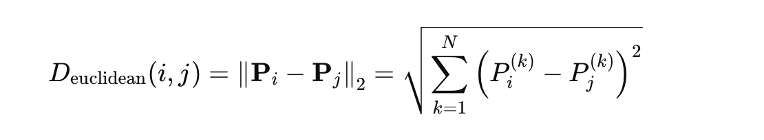


Pi and Pj are normalized RSRP vectors at receiver sites i and j, respectively.

Pi(k): normalized RSRP from transmitter k at receiver i.

N: number of transmitters

Here, Euclidean distances are computed between each test receiver’s normalized RSRP vector and all training receivers’ vectors. This represents the signal-space similarity between locations, forming the foundation for inferring test positions based on training data.


In [ ]:
# ---- Step 7: Euclidean distance between test and training RSRP vectors
num_test = RSRP_test.shape[1]
num_train = RSRP_train.shape[1]
euclidean_dist_test_to_train = np.zeros((num_test, num_train))

for test_idx in range(num_test):
    for train_idx in range(num_train):
        dist = np.linalg.norm(normalized_rsrp_test[:, test_idx] - normalized_rsrp_train[:, train_idx])
        euclidean_dist_test_to_train[test_idx, train_idx] = dist


For each test receiver, pick the training receiver with the minimum Euclidean distance in RSRP space as the predicted location.

Each test receiver is matched to the most similar training receiver based on the smallest Euclidean distance in signal space. This reflects a k-nearest neighbor approach (k=1), identifying the test receiver’s likely position by its RSRP profile resemblance.

In [ ]:
# ---- Step 8: Predicted indices by minimum Euclidean distance
predicted_indices = np.argmin(euclidean_dist_test_to_train, axis=1)


This step identifies the physically closest training receiver to each test receiver using ECEF coordinates. It serves as ground truth to evaluate the prediction model, comparing inferred signal-space similarity with actual spatial proximity.

In [ ]:
# ---- Step 9: True nearest training index by geographic proximity
def latlon_to_ecef(lat_deg, lon_deg):
    lat_rad = np.radians(lat_deg)
    lon_rad = np.radians(lon_deg)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.stack((x, y, z), axis=1)

train_xyz = latlon_to_ecef(rx_lats_train, rx_lons_train)
test_xyz = latlon_to_ecef(rx_test_lats, rx_test_lons)

true_indices = np.zeros(num_test, dtype=int)
for i in range(num_test):
    dists = np.linalg.norm(train_xyz - test_xyz[i, :], axis=1)
    true_indices[i] = np.argmin(dists)



# === FIGURE 1: Plot Manhattan buildings + TX + RX (training + test) ===
fig, ax = plt.subplots(figsize=(12, 12))
buildings.plot(ax=ax, color='lightgray', edgecolor='none')
ax.scatter(tx_lons, tx_lats, marker='^', s=200, color='red', label='Transmitters (Tx)')
ax.scatter(rx_lons_train, rx_lats_train, marker='o', s=80, color='blue', label='Training Receivers (Rx)')
ax.scatter(rx_test_lons, rx_test_lats, marker='x', s=80, color='green', label='Test Receivers (Rx)')
ax.set_title('Manhattan Buildings with Transmitters and Receivers')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.show()

# === FIGURE 2: Euclidean distance plots for test receivers R1, R16, R32 ===
test_indices_to_plot = [0, 15, 31]  # Python 0-based: R1=0, R16=15, R32=31

for idx in test_indices_to_plot:
    plt.figure()
    plt.plot(range(1, num_train + 1), euclidean_dist_test_to_train[idx, :], 'o-b')
    plt.xlabel('Training Receiver Index')
    plt.ylabel('Euclidean Distance')
    plt.title(f'Euclidean Distance from Test Receiver {idx + 1} to Training Receivers')
    plt.xticks(range(1, num_train + 1))
    plt.grid(True)
    plt.show()



# ---- Step 11: Print accuracy
accuracy = np.trace(confMat) / np.sum(confMat)
print(f"Prediction Accuracy: {accuracy*100:.2f}%")


The physical distance is calculated using the Haversine formula, which determines the great-circle distance between two points on the Earth's surface using their GPS coordinates (latitude and longitude). In the code, this represents the actual real-world distance between receiver locations. It provides a ground truth to compare against the fingerprint-based (Euclidean) distances and assess how signal similarity relates to physical proximity.

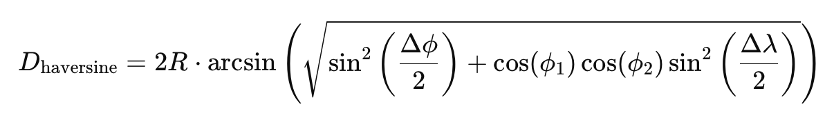

R: earth's radius (6,371,000 meters)

ϕ1, ϕ2: latitudes (in radians)

λ1, λ2: longitudes (in radians)

Δϕ = ϕ2−ϕ1, Δλ = λ2−λ1


In [ ]:
# Distance calculations from R1, R2, R3 to others
euclidean_R = np.zeros((3, num_train_rx - 1))
physical_R = np.zeros((3, num_train_rx - 1))

def haversine(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
    return 2 * earth_radius * np.arcsin(np.sqrt(a))

# For each of R1-R3
for r in range(3):  # 0-based index for R1, R2, R3
    ref_rsrp = normalized_rsrp_train[:, r]
    ref_lat = rx_lats_train[r]
    ref_lon = rx_lons_train[r]

    offset = 0
    for i in range(num_train_rx):
        if i == r:
            continue  # skip comparison to self
        # Euclidean (RSRP-based)
        euclidean_R[r, offset] = np.linalg.norm(ref_rsrp - normalized_rsrp_train[:, i])

        # Physical (Haversine)
        physical_R[r, offset] = haversine(ref_lat, ref_lon, rx_lats_train[i], rx_lons_train[i])
        offset += 1


# Plot Euclidean vs. Physical distances for R1, R2, R3
for r in range(3):  # R1 to R3
    fig, ax1 = plt.subplots()

    ax2 = ax1.twinx()

    # X-axis: index of other receivers (excluding the reference one)
    x_vals = np.arange(num_train_rx - 1)

    # Left Y-axis: Euclidean
    p1 = ax1.plot(x_vals, euclidean_R[r], 'o-b', label='Euclidean Distance')
    ax1.set_ylabel('Euclidean Distance', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    # Right Y-axis: Physical
    p2 = ax2.plot(x_vals, physical_R[r], 'o-r', label='Physical Distance (m)')
    ax2.set_ylabel('Physical Distance (m)', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    ax1.set_xlabel('Receiver Index (Excl. R{})'.format(r + 1))
    plt.title(f'Distance Comparison for Receiver R{r + 1}')
    fig.tight_layout()
    plt.grid(True)
    plt.xticks(x_vals)
    plt.show()


These are some differents coordinates of transmitters than can be used. The goal is to see how they affect the RSRP since they play an important role on it.


In [ ]:
# Transmitter positions (lat/lon)
tx_lats = np.array([40.7785, 40.7784, 40.7824])
tx_lons = np.array([-73.9703, -73.9642, -73.9647])
tx_antenna_height = 78

In [ ]:
# Transmitter positions (lat/lon)
tx_lats = np.array([40.7785, 40.7795, 40.7833])
tx_lons = np.array([-73.9703, -73.9652, -73.9661])
tx_antenna_height = 78